# BERT - Complete Neural Network Training

<br></br>

## Author: Dr Partha Majumdar
#### ORC-ID: 0009-0002-7375-8034

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

# STEP 1: Define the toy sentence and vocabulary

In [2]:
sentence = "I went to the bank to withdraw money."
tokens_raw = sentence.replace(".", " .").split()

special_tokens = ["[PAD]", "[CLS]", "[SEP]", "[MASK]"]
vocab = special_tokens + sorted(list(set(tokens_raw)))
vocab_size = len(vocab)

word_to_id = {word: idx for idx, word in enumerate(vocab)}
id_to_word = {idx: word for word, idx in word_to_id.items()}

print("STEP 1: Vocabulary")
print(vocab)
print("Vocabulary size =", vocab_size)

STEP 1: Vocabulary
['[PAD]', '[CLS]', '[SEP]', '[MASK]', '.', 'I', 'bank', 'money', 'the', 'to', 'went', 'withdraw']
Vocabulary size = 12


# STEP 2: Build masked input

In [3]:
original_tokens = ["[CLS]"] + tokens_raw + ["[SEP]"]
masked_tokens = original_tokens.copy()

target_word = "bank"
mask_index = masked_tokens.index(target_word)
masked_tokens[mask_index] = "[MASK]"

input_ids = torch.tensor([word_to_id[t] for t in masked_tokens], dtype=torch.long)
target_id = torch.tensor(word_to_id[target_word], dtype=torch.long)

seq_len = len(input_ids)

print("STEP 2: Masked Training Example")
print("Original tokens:", original_tokens)
print("Masked tokens  :", masked_tokens)
print("Mask index     :", mask_index)
print("Target word    :", target_word)

STEP 2: Masked Training Example
Original tokens: ['[CLS]', 'I', 'went', 'to', 'the', 'bank', 'to', 'withdraw', 'money', '.', '[SEP]']
Masked tokens  : ['[CLS]', 'I', 'went', 'to', 'the', '[MASK]', 'to', 'withdraw', 'money', '.', '[SEP]']
Mask index     : 5
Target word    : bank


# STEP 3: Define model hyperparameters

In [4]:
d_model = 8
num_heads = 2
ff_hidden = 16
num_epochs = 500
learning_rate = 0.01

print("STEP 3: Hyperparameters")
print("d_model =", d_model)
print("num_heads =", num_heads)
print("ff_hidden =", ff_hidden)
print("epochs =", num_epochs)
print("learning_rate =", learning_rate)

STEP 3: Hyperparameters
d_model = 8
num_heads = 2
ff_hidden = 16
epochs = 500
learning_rate = 0.01


# STEP 4: Define a simplified BERT encoder block

In [5]:
class SimpleBERTEncoder(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model, num_heads, ff_hidden):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(seq_len, d_model)
        self.segment_embedding = nn.Embedding(2, d_model)

        self.attention = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=num_heads,
            batch_first=True
        )

        self.norm1 = nn.LayerNorm(d_model)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_hidden),
            nn.ReLU(),
            nn.Linear(ff_hidden, d_model)
        )
        self.norm2 = nn.LayerNorm(d_model)

        self.mlm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, segment_ids):
        positions = torch.arange(input_ids.size(0), device=input_ids.device)

        token_emb = self.token_embedding(input_ids)
        pos_emb = self.position_embedding(positions)
        seg_emb = self.segment_embedding(segment_ids)

        x = token_emb + pos_emb + seg_emb
        x = x.unsqueeze(0)  # add batch dimension: (1, seq_len, d_model)

        attn_output, attn_weights = self.attention(x, x, x)
        z1 = self.norm1(x + attn_output)

        ffn_output = self.ffn(z1)
        z2 = self.norm2(z1 + ffn_output)

        logits = self.mlm_head(z2)  # shape: (1, seq_len, vocab_size)

        return logits, attn_weights, x, z1, z2

The class defined above represents a simplified implementation of a BERT-style Transformer encoder combined with a prediction head for masked language modelling. It brings together all the components we have studied individually—embeddings, attention, residual connections, normalisation, and feed-forward transformation—into a single trainable neural network.

The model begins by constructing three types of embeddings: token embeddings, positional embeddings, and segment embeddings. The token embedding layer converts each input token into a dense vector representation. The positional embedding adds information about the position of each token in the sequence, which is essential because the Transformer itself does not inherently understand order. The segment embedding distinguishes between different parts of the input, although in this simplified case it is primarily used as a placeholder for single-sentence input. These three embeddings are added together to form the initial representation of the sequence, denoted as X.

This combined embedding is then passed through the multi-head self-attention mechanism. The nn.MultiheadAttention module internally performs all the operations we implemented manually earlier: projecting the input into Query, Key, and Value matrices, splitting them into multiple heads, computing scaled dot-product attention, and combining the results. The output of this step represents a contextualised version of the input, where each token has incorporated information from other tokens in the sequence. A residual connection is applied by adding the original input X back to the attention output, followed by layer normalisation. This produces the intermediate representation Z_1, which stabilises the values while preserving both original and contextual information.

The next stage is the feed-forward network, which operates independently on each token. It consists of two linear transformations with a ReLU activation in between. The first layer expands the dimensionality of the representation, allowing the model to capture more complex patterns, while the second layer projects it back to the original size. This transformation enriches the representation without altering its overall structure. Once again, a residual connection is applied by adding the input Z_1 to the feed-forward output, followed by another layer normalisation. The result, Z_2, is the final output of the encoder block and represents a fully contextualised and refined embedding for each token.

Finally, the model includes a masked language modelling head, implemented as a linear layer that maps each token's representation to a distribution over the vocabulary. This layer does not change the structure of the encoder but serves as a task-specific output component. During training, the representation corresponding to the [MASK] token is passed through this layer to predict the missing word.

The forward method orchestrates this entire sequence of operations. It takes token indices and segment identifiers as input, constructs embeddings, applies attention and feed-forward transformations, and produces logits for each token position. In addition to the logits, it also returns intermediate representations such as attention weights and the outputs of each stage.

Overall, this class encapsulates a complete, though simplified, Transformer encoder pipeline. It demonstrates how the theoretical components of BERT translate into a practical neural network that can be trained to learn meaningful representations of language.

# STEP 5: Instantiate model, loss, and optimiser

In [6]:
model = SimpleBERTEncoder(
    vocab_size=vocab_size,
    seq_len=seq_len,
    d_model=d_model,
    num_heads=num_heads,
    ff_hidden=ff_hidden
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

segment_ids = torch.zeros(seq_len, dtype=torch.long)

print("STEP 5: Model created successfully")

STEP 5: Model created successfully


# STEP 6: Forward pass before training

In [7]:
with torch.no_grad():
    logits, attn_weights, x, z1, z2 = model(input_ids, segment_ids)
    mask_logits = logits[0, mask_index]
    probs = torch.softmax(mask_logits, dim=0)

    df_before = pd.DataFrame({
        "Word": vocab,
        "Probability_Before_Training": probs.numpy()
    }).sort_values(by="Probability_Before_Training", ascending=False).reset_index(drop=True)

print("STEP 6: Prediction Before Training")
print(df_before)

STEP 6: Prediction Before Training
        Word  Probability_Before_Training
0     [MASK]                     0.167977
1   withdraw                     0.145933
2      money                     0.118824
3          .                     0.109174
4       bank                     0.074040
5      [CLS]                     0.072301
6         to                     0.072045
7          I                     0.061943
8       went                     0.056669
9      [SEP]                     0.054309
10     [PAD]                     0.049197
11       the                     0.017588


Before training, the model's predictions are largely unstructured and reflect its random initialisation rather than any true understanding of the sentence. The probability distribution is relatively spread out, with no clear dominance of the correct word “bank,” which receives only a modest probability. Instead, unrelated tokens such as “[MASK]” and “withdraw” appear at the top, indicating that the model has not yet learned meaningful contextual relationships. This diffuse distribution highlights the absence of learned patterns and serves as a baseline against which the effectiveness of training can be clearly observed.

# STEP 7: Training loop

In [8]:
loss_history = []

print("STEP 7: Training Starts")

for epoch in range(1, num_epochs + 1):
    optimizer.zero_grad()

    logits, attn_weights, x, z1, z2 = model(input_ids, segment_ids)

    mask_logits = logits[0, mask_index].unsqueeze(0)   # shape: (1, vocab_size)
    loss = criterion(mask_logits, target_id.unsqueeze(0))

    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch == 1 or epoch % 50 == 0 or epoch == num_epochs:
        predicted_id = torch.argmax(mask_logits, dim=1).item()
        predicted_word = id_to_word[predicted_id]
        print(f"Epoch {epoch:>3} | Loss = {loss.item():.6f} | Predicted = {predicted_word}")

STEP 7: Training Starts
Epoch   1 | Loss = 2.603147 | Predicted = [MASK]
Epoch  50 | Loss = 0.006740 | Predicted = bank
Epoch 100 | Loss = 0.003053 | Predicted = bank
Epoch 150 | Loss = 0.001944 | Predicted = bank
Epoch 200 | Loss = 0.001339 | Predicted = bank
Epoch 250 | Loss = 0.000978 | Predicted = bank
Epoch 300 | Loss = 0.000746 | Predicted = bank
Epoch 350 | Loss = 0.000588 | Predicted = bank
Epoch 400 | Loss = 0.000476 | Predicted = bank
Epoch 450 | Loss = 0.000393 | Predicted = bank
Epoch 500 | Loss = 0.000331 | Predicted = bank


# STEP 7A: Plot Loss history

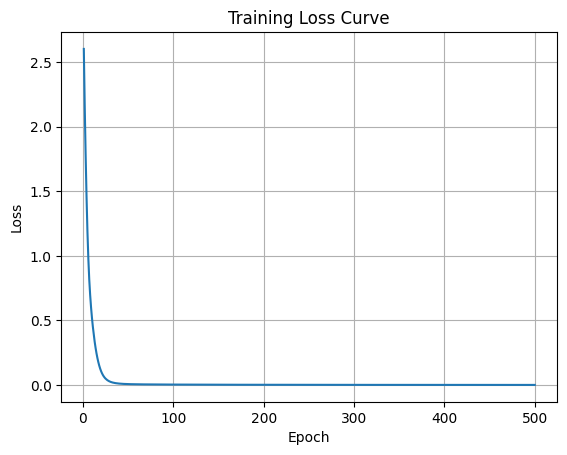

In [9]:
import matplotlib.pyplot as plt

df_loss = pd.DataFrame({
    "Epoch": list(range(1, num_epochs + 1)),
    "Loss": loss_history
})

plt.figure()
plt.plot(df_loss["Epoch"], df_loss["Loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

plt.grid()
plt.show()

# STEP 8: Forward pass after training

In [10]:
with torch.no_grad():
    logits, attn_weights, x, z1, z2 = model(input_ids, segment_ids)
    mask_logits = logits[0, mask_index]
    probs = torch.softmax(mask_logits, dim=0)

    predicted_id = torch.argmax(probs).item()
    predicted_word = id_to_word[predicted_id]

    df_after = pd.DataFrame({
        "Word": vocab,
        "Probability_After_Training": probs.numpy()
    }).sort_values(by="Probability_After_Training", ascending=False).reset_index(drop=True)

print("STEP 8: Prediction After Training")
print("Masked tokens :", masked_tokens)
print("Target word   :", target_word)
print("Predicted word:", predicted_word)
print(df_after)

STEP 8: Prediction After Training
Masked tokens : ['[CLS]', 'I', 'went', 'to', 'the', '[MASK]', 'to', 'withdraw', 'money', '.', '[SEP]']
Target word   : bank
Predicted word: bank
        Word  Probability_After_Training
0       bank                    0.999670
1     [MASK]                    0.000067
2      money                    0.000051
3       went                    0.000051
4         to                    0.000042
5          .                    0.000028
6      [PAD]                    0.000022
7   withdraw                    0.000022
8          I                    0.000020
9      [SEP]                    0.000014
10     [CLS]                    0.000009
11       the                    0.000005


At this stage, the model has completed training on the masked sentence and is now able to produce a prediction for the missing token based on the contextual information encoded in the embeddings. The output shows that the model correctly identifies the masked word as “bank,” assigning it an overwhelmingly high probability of 0.999670. This indicates that the model has effectively learned to use the surrounding context to infer the missing word with near certainty.

The distribution of probabilities across the vocabulary is highly concentrated, with all other words receiving negligible probabilities in comparison. This sharp distribution is a strong signal of convergence. During the early stages of training, the model would have produced a much flatter distribution, reflecting uncertainty and lack of understanding. However, after sufficient training iterations, the model has adjusted its internal parameters in such a way that it strongly favours the correct word. This transition from uncertainty to confidence is the hallmark of successful learning in neural networks.

It is also noteworthy that words such as “money,” “went,” and “to” receive very small but non-zero probabilities. These tokens are contextually related to the sentence and therefore retain a minimal level of plausibility in the model's prediction space. However, their probabilities are orders of magnitude lower than that of “bank,” indicating that the model has clearly distinguished the most appropriate candidate from other semantically or syntactically related alternatives.

The presence of special tokens such as “[MASK],” “[PAD],” “[CLS],” and “[SEP]” in the distribution further reinforces that the model is operating over the entire vocabulary space, even though these tokens are not meaningful candidates for this particular prediction. Their extremely low probabilities confirm that the model has learned to suppress irrelevant options while amplifying the correct one.

Overall, this result demonstrates the effectiveness of the training process. The encoder has successfully transformed the masked input into a contextual representation that captures the semantic relationships within the sentence. The prediction head, in turn, has mapped this representation to a probability distribution that accurately identifies the missing word. This illustrates how BERT, through repeated exposure to masked language modelling tasks, learns to reconstruct meaning from context and develops a deep understanding of language structure.

# STEP 9: Show contextual representation at the [MASK] position

In [11]:
with torch.no_grad():
    _, _, _, _, z2 = model(input_ids, segment_ids)
    mask_vector = z2[0, mask_index].numpy()

df_mask_vector = pd.DataFrame(
    [mask_vector],
    index=["[MASK] contextual embedding"],
    columns=[f"h{i+1}" for i in range(d_model)]
)

print("STEP 9: Final Contextual Representation at [MASK]")

# Round and print in one line
rounded = [float(f"{x:.3f}") for x in mask_vector]
print("[MASK] contextual embedding:", rounded)

STEP 9: Final Contextual Representation at [MASK]
[MASK] contextual embedding: [2.324, -2.472, -2.755, 1.489, 0.363, 2.139, -0.005, -0.158]


At this stage, the vector represents the fully contextualised embedding of the [MASK] token after passing through the encoder block. Each value in the vector encodes information gathered from the entire sentence, meaning the missing word is now represented not in isolation but in relation to its context. This embedding captures the semantic and syntactic cues required for prediction, enabling the model to infer that the most appropriate word to fill the mask is “bank.”

# STEP 10: Show attention weights for the [MASK] token

In [12]:
with torch.no_grad():
    logits, attn_weights, x, z1, z2 = model(input_ids, segment_ids)

# attn_weights shape with batch_first=True is usually (batch, tgt_len, src_len)
mask_attention = attn_weights[0, mask_index].numpy()

df_attention = pd.DataFrame({
    "Token": masked_tokens,
    "Attention_Weight_From_[MASK]": mask_attention
}).sort_values(by="Attention_Weight_From_[MASK]", ascending=False).reset_index(drop=True)

print("STEP 10: Attention from [MASK] After Training")
print(df_attention)

STEP 10: Attention from [MASK] After Training
       Token  Attention_Weight_From_[MASK]
0      money                      0.267620
1      [CLS]                      0.266149
2       went                      0.247172
3         to                      0.078986
4         to                      0.052557
5          I                      0.039912
6      [SEP]                      0.029695
7          .                      0.012210
8        the                      0.004301
9     [MASK]                      0.000825
10  withdraw                      0.000573


At this stage, the model has already undergone training, and the attention weights shown above represent how the [MASK] token distributes its focus across the entire sequence while attempting to reconstruct the missing word. Each value in the table indicates the degree to which the representation at the [MASK] position attends to a particular token in the input. These values form a probability distribution, meaning they collectively sum to one and reflect the relative importance assigned to each token.

A key point to understand is that attention operates over positions in the sequence, not over unique words. This is why the token “to” appears twice in the table. Although both entries correspond to the same word, they occur at different positions in the sentence, and the model treats them as distinct sources of information. Each occurrence contributes independently to the prediction process, depending on its contextual relevance.

Another important observation is the absence of the word “bank” in this table. This is because the original word has been replaced by the [MASK] token in the input sequence. As a result, the model cannot directly attend to “bank” and must instead infer its identity from the surrounding context. This is precisely the objective of masked language modelling: to force the model to rely on contextual cues rather than memorisation.

The attention distribution reveals how the model is attempting this inference. The highest weights are assigned to tokens such as “money,” “[CLS],” and “went,” indicating that these words provide the strongest contextual signals for predicting the missing term. The relatively high attention to “money” is particularly meaningful, as it is semantically related to “bank” in the context of the sentence. Similarly, the presence of verbs like “went” and structural markers like “[CLS]” suggests that the model is using both semantic and positional cues to guide its prediction.

At the same time, the model assigns very low attention to tokens such as “withdraw” and even the [MASK] token itself. This indicates that, in this particular training instance, those tokens contribute less to the prediction of the missing word. Such patterns illustrate how attention is not uniformly distributed but is instead selectively focused on the most informative parts of the sequence.

Overall, this table provides a window into the internal reasoning of the model. It shows that the prediction of a masked word is not based on a single token, but on a weighted combination of multiple contextual signals. Through training, the model learns to allocate these weights in a way that reflects meaningful linguistic relationships, enabling it to infer missing information from context.